## Model Evaluation
---

In [2]:
"""
Set up the Python path so that the repo-root package `models.classification` is importable,
then pull in PyTorch, standard data-science libraries, and all project modules needed for
loading the trained classifier, running inference, and plotting results.
"""

import sys
from pathlib import Path

# Add ChordEdit root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader

from models.classification.model import OrdinalPairClassifier, mae_buckets
from models.classification.head_coral import decode_ordinal
from models.classification.head_mse import decode_regression
from models.classification.classify import PairDataset, collate, eval_loader

from settings import *


### 1. Load Data

In [3]:
"""
Locate the most recent timestamped run directory under OUTPUTS_DIR and load the
train/val/test DataFrames that were saved as gzip-compressed Parquet files during
training. Printing the bucket lists confirms that the split was built from the expected
set of discrete t_start and t_end values.
"""

from models.classification.settings import OUTPUTS_DIR

run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories found in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
print(f"Using run: {RUN_DIR.name}")

train_df = pd.read_parquet(RUN_DIR / "train.parquet.gz")
val_df   = pd.read_parquet(RUN_DIR / "val.parquet.gz")
test_df  = pd.read_parquet(RUN_DIR / "test.parquet.gz")

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"t_start buckets: {sorted(train_df['t_start'].unique())}")
print(f"t_end   buckets: {sorted(train_df['t_end'].unique())}")
test_df


Using run: 20260623_161329
train: 560  val: 70  test: 70
t_start buckets: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
t_end   buckets: [np.float64(0.3)]


,sample_id,t_start,t_end,id,source_prompt,target_prompt,t_start_idx,t_end_idx
0,000000000004,0.6,0.3,000000000004,a cat sitting next to a mirror,a [silver] cat [sculpture] sitting next to a m...,6,0
1,000000000013,0.5,0.3,000000000013,three white [dumplings] on brown bowl,three white [sushi] on brown bowl,5,0
2,000000000014,0.9,0.3,000000000014,a man with his hands [hanging down] standing b...,a man with his hands [rasing] standing by a house,9,0
3,000000000027,0.9,0.3,000000000027,a [opened] eyes cat sitting on wooden floor,a [closed] eyes cat sitting on wooden floor,9,0
4,000000000032,0.8,0.3,000000000032,a group of [pink] flowers hanging from a tree,a group of [red] flowers hanging from a tree,8,0
...,...,...,...,...,...,...,...,...
65,913000000006,0.5,0.3,913000000006,"a desk with a laptop, a plant, and a mouse","[a brush painting of] a desk with a laptop, a ...",5,0
66,921000000001,0.5,0.3,921000000001,a rat is peeking out from behind a pink wall,[a digital art of] a rat is peeking out from b...,5,0
67,921000000003,1.0,0.3,921000000003,a bernese mountain dog is sitting in the grass,[stained glass window of] a bernese mountain d...,10,0
68,924000000003,0.9,0.3,924000000003,wind turbine in the sunset,[pen and ink sketch of] wind turbine in the su...,9,0


### 2. Load Model

In [4]:
"""
Load the best checkpoint saved during training, reconstruct an OrdinalPairClassifier with
the same architecture settings stored in the checkpoint config, and restore the saved
weights. Also derives convenience arrays of bucket float values and display labels used
by all downstream plotting cells.
"""

from models.classification.settings import FREEZE_ENCODER

weights_path = RUN_DIR / "classifier_weights.pt"
assert weights_path.exists(), f"No weights found in {RUN_DIR}"
print(f"Loading: {weights_path}  (run: {RUN_DIR.name})\n")

ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
buckets_start = torch.tensor(ckpt["buckets1"], dtype=torch.float)
buckets_end   = torch.tensor(ckpt["buckets2"], dtype=torch.float)
HEAD_TYPE     = ckpt.get("config", {}).get("HEAD_TYPE", "CORAL")

print("Checkpoint settings:")
for k, v in ckpt.get("config", {}).items():
    print(f"  {k:<25} {v}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrdinalPairClassifier(
    buckets1=buckets_start, buckets2=buckets_end,
    freeze_encoder=FREEZE_ENCODER, head_type=HEAD_TYPE,
).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"\nDevice: {DEVICE}")

bucket_vals_start = buckets_start.numpy()
bucket_vals_end   = buckets_end.numpy()
N_BUCKETS_START   = len(bucket_vals_start)
N_BUCKETS_END     = len(bucket_vals_end)
BUCKET_LABELS_START = [f"{v:.3g}" for v in bucket_vals_start]
BUCKET_LABELS_END   = [f"{v:.3g}" for v in bucket_vals_end]
print(f"t_start: {N_BUCKETS_START} buckets {BUCKET_LABELS_START}")
print(f"t_end:   {N_BUCKETS_END} buckets {BUCKET_LABELS_END}")


Loading: /data/home/mirick/ChordEdit/models/classification/outputs/sdxlturbo_tstart/20260623_161329/classifier_weights.pt  (run: 20260623_161329)

Checkpoint settings:
  run_dir                   /data/home/mirick/ChordEdit/models/classification/outputs/sdxlturbo_tstart/20260623_161329
  DATA_DIR                  /data/home/mirick/ChordEdit/models/classification/data
  METRICS_CSV               /data/home/mirick/ChordEdit/models/classification/data/id_to_metrics_sdxlturbo_tstart.csv
  STRINGS_CSV               /data/home/mirick/ChordEdit/models/classification/data/id_to_string_pair.csv
  OUTPUTS_DIR               /data/home/mirick/ChordEdit/models/classification/outputs/sdxlturbo_tstart
  N_BUCKETS_START           11
  N_BUCKETS_END             1
  T_DELTA_TARGET            0.0
  PAPER_T_START             0.9
  PAPER_T_END               0.3
  PAPER_T_DELTA             0.15
  COMPUTED_METRIC_COL       naive_pareto_score
  COMPUTED_METRIC_FN        compute_naive_pareto_score
  COMPUTED_M

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9693.13it/s]
/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")



Device: cuda
t_start: 11 buckets ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']
t_end:   1 buckets ['0.3']


### 3. Run Inference on All Splits

In [5]:
"""
Run the trained model in eval mode over the train, val, and test DataLoaders, collecting
predicted bucket indices, true bucket indices, and raw head outputs (logits for CORAL,
sigmoid scalars for MSE) for both t_start and t_end. Results are stored in a dict keyed
by split name so all downstream cells can access them without re-running inference.
"""

from models.classification.settings import BATCH_SIZE

def predict_split(df: pd.DataFrame) -> dict:
    """Return dict with pred/true arrays for both heads."""
    loader = DataLoader(PairDataset(df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    p1_list, p2_list, l1_list, l2_list = [], [], [], []
    raw1_list, raw2_list = [], []
    with torch.no_grad():
        for srcs, tgts, l1, l2 in loader:
            l1, l2 = l1.to(DEVICE), l2.to(DEVICE)
            out1, out2 = model(srcs, tgts)
            if model.head_type == "CORAL":
                p1_list.append(decode_ordinal(out1).cpu())
                p2_list.append(decode_ordinal(out2).cpu())
            else:
                p1_list.append(decode_regression(out1, model.buckets1).cpu())
                p2_list.append(decode_regression(out2, model.buckets2).cpu())
            raw1_list.append(out1.cpu())
            raw2_list.append(out2.cpu())
            l1_list.append(l1.cpu())
            l2_list.append(l2.cpu())
    return {
        "pred_start": torch.cat(p1_list).numpy(),
        "pred_end":   torch.cat(p2_list).numpy(),
        "true_start": torch.cat(l1_list).numpy(),
        "true_end":   torch.cat(l2_list).numpy(),
        "raw_start":  torch.cat(raw1_list).numpy(),
        "raw_end":    torch.cat(raw2_list).numpy(),
    }

results = {
    "train": predict_split(train_df),
    "val":   predict_split(val_df),
    "test":  predict_split(test_df),
}
print("Inference complete.")


Inference complete.


### 4. Metrics Summary

In [6]:
"""
Compute per-split accuracy and MAE for both heads and display them as a color-gradient
table, where green indicates better performance. The random-chance baseline for accuracy
is 1/N_BUCKETS, so any value above that indicates the model has learned something.
"""

def compute_metrics(r: dict) -> dict:
    p1 = torch.tensor(r["pred_start"])
    p2 = torch.tensor(r["pred_end"])
    t1 = torch.tensor(r["true_start"])
    t2 = torch.tensor(r["true_end"])
    return {
        "mae_start":  mae_buckets(p1, t1).item(),
        "mae_end":    mae_buckets(p2, t2).item(),
        "acc_start":  (p1 == t1).float().mean().item(),
        "acc_end":    (p2 == t2).float().mean().item(),
        "acc_both":   ((p1 == t1) & (p2 == t2)).float().mean().item(),
    }

metrics_df = pd.DataFrame(
    {split: compute_metrics(r) for split, r in results.items()}
).T.rename(columns={
    "mae_start": "MAE t_start",
    "mae_end":   "MAE t_end",
    "acc_start": "Acc t_start",
    "acc_end":   "Acc t_end",
    "acc_both":  "Joint Acc",
})
metrics_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=0)


,MAE t_start,MAE t_end,Acc t_start,Acc t_end,Joint Acc
train,2.598,0.000,0.138,1.000,0.138
val,2.700,0.000,0.071,1.000,0.071
test,2.700,0.000,0.143,1.000,0.143


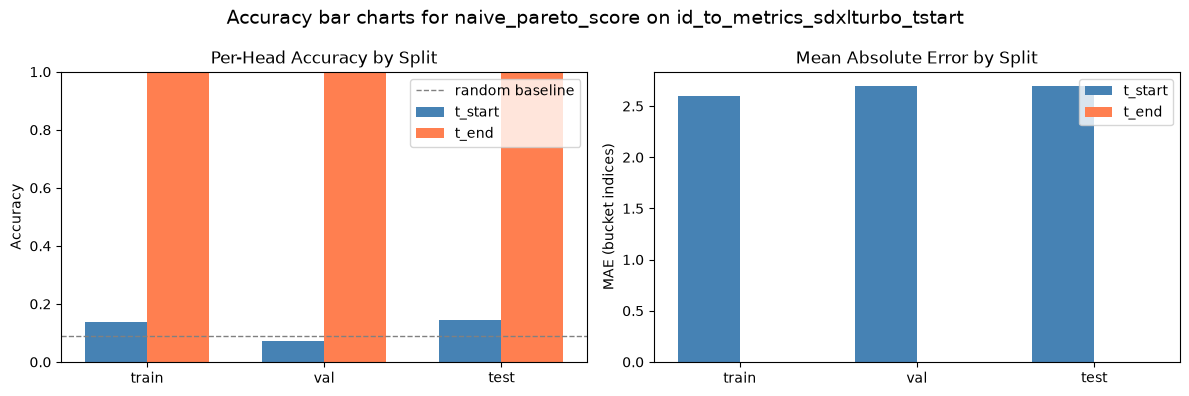

In [7]:
"""
Plot grouped bar charts comparing per-head accuracy and MAE across train, val, and test
splits. The dashed line on the accuracy panel marks random-chance performance so it is
visually clear how far above (or below) chance the model lands for each head.
"""

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = ["train", "val", "test"]
x = np.arange(len(splits))
width = 0.35

# Accuracy panel
ax = axes[0]
m = {s: compute_metrics(results[s]) for s in splits}
ax.bar(x - width/2, [m[s]["acc_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["acc_end"]   for s in splits], width, label="t_end",   color="coral")
ax.axhline(1/N_BUCKETS_START, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Accuracy"); ax.set_title("Per-Head Accuracy by Split")
ax.set_ylim(0, 1); ax.legend()

# MAE panel
ax = axes[1]
ax.bar(x - width/2, [m[s]["mae_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["mae_end"]   for s in splits], width, label="t_end",   color="coral")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("MAE (bucket indices)"); ax.set_title("Mean Absolute Error by Split")
ax.legend()

fig.suptitle(f"Accuracy bar charts for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


### 5. Confusion Matrices

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


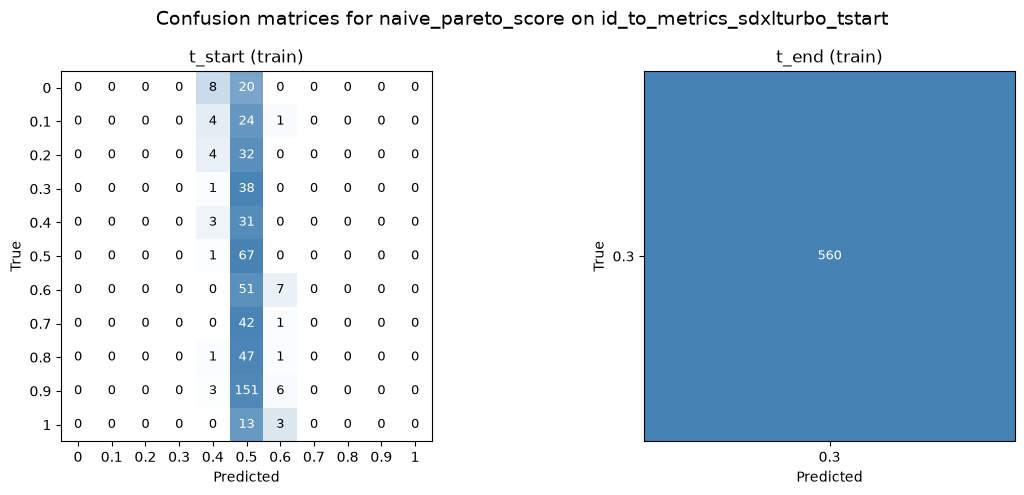

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


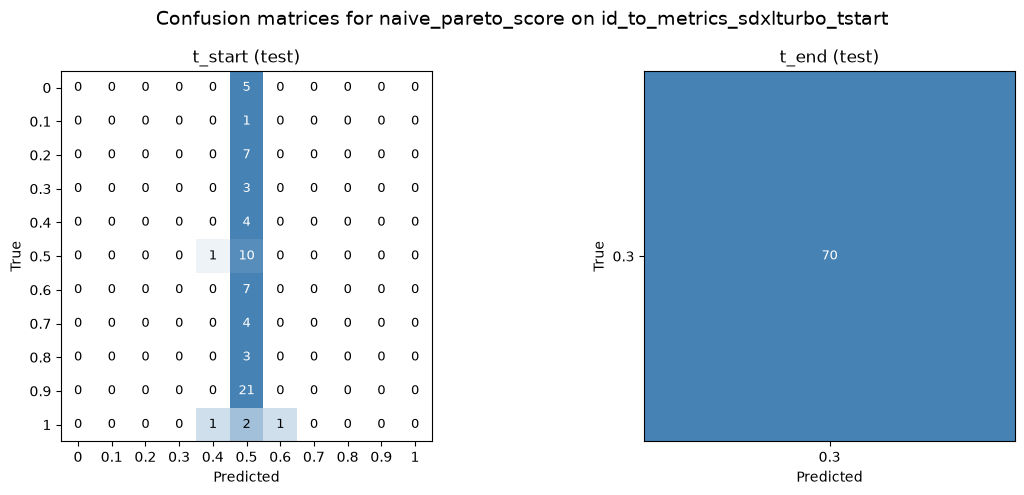

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


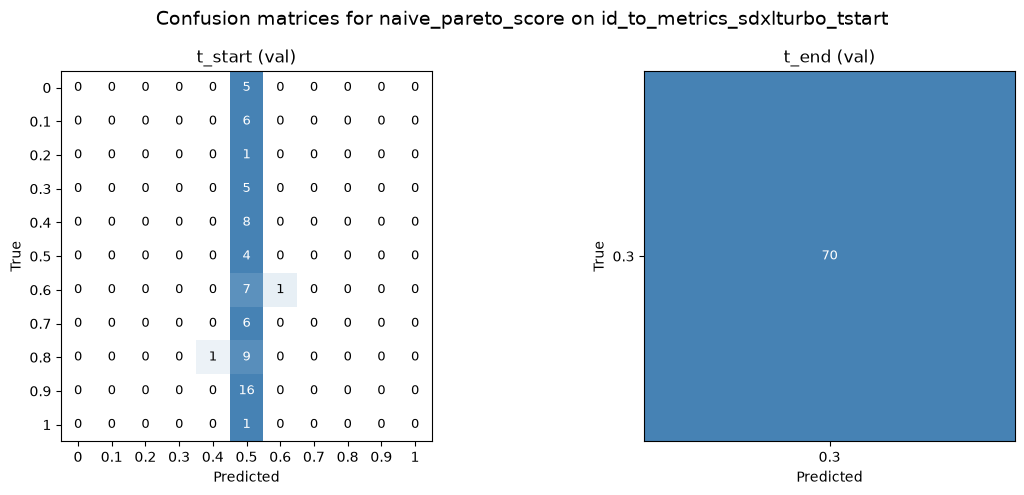

In [8]:
"""
Plot row-normalised confusion matrices for both heads across all three splits. Each cell
shows the raw count as a number and is shaded by the fraction of true-class samples that
fell in that predicted bucket, making it easy to see whether errors cluster near the
diagonal (near-miss) or scatter widely (large mistakes).
"""

from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title, bucket_labels):
    n_buckets = len(bucket_labels)

    cm = confusion_matrix(true, pred, labels=list(range(n_buckets)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

    for i in range(n_buckets):
        for j in range(n_buckets):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=9, color="white" if cm_norm[i, j] > 0.5 else "black")

    ax.set_xticks(range(n_buckets))
    ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels)
    ax.set_yticklabels(bucket_labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    return im

def plot_split(split):
    r = results[split]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_confusion(axes[0], r["true_start"], r["pred_start"], f"t_start ({split})", BUCKET_LABELS_START)
    plot_confusion(axes[1], r["true_end"], r["pred_end"], f"t_end ({split})", BUCKET_LABELS_END)
    fig.suptitle(f"Confusion matrices for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)

    plt.tight_layout()  # leave space for suptitle
    plt.show()
    plt.close(fig)

for split in ["train", "test", "val"]:
    plot_split(split)


### 6. Error Distribution

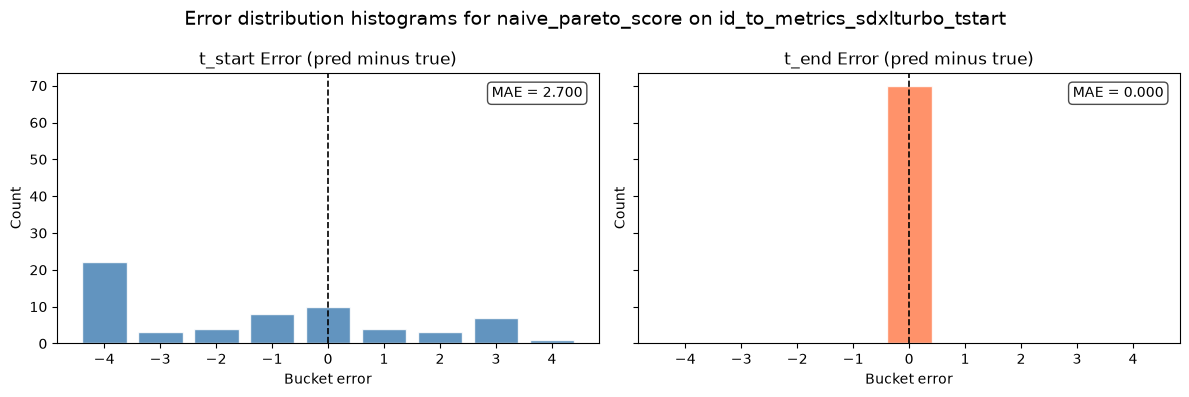

In [9]:
"""
Plot signed bucket-index error histograms (predicted minus true) for both heads on the
test set. A perfectly calibrated model would produce a spike at zero; mass shifted left
or right indicates systematic over- or under-prediction. The MAE is annotated directly
on each panel for quick reference.
"""

r = results["test"]
err_start = r["pred_start"] - r["true_start"]
err_end   = r["pred_end"]   - r["true_end"]

bins = np.arange(-4.5, 5.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, err, title, color in [
    (axes[0], err_start, "t_start Error (pred minus true)", "steelblue"),
    (axes[1], err_end,   "t_end Error (pred minus true)",   "coral"),
]:
    counts, edges = np.histogram(err, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, counts, width=0.8, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Bucket error")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    mae_val = np.abs(err).mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle(f"Error distribution histograms for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


### 7. Predicted vs. True Class Distributions

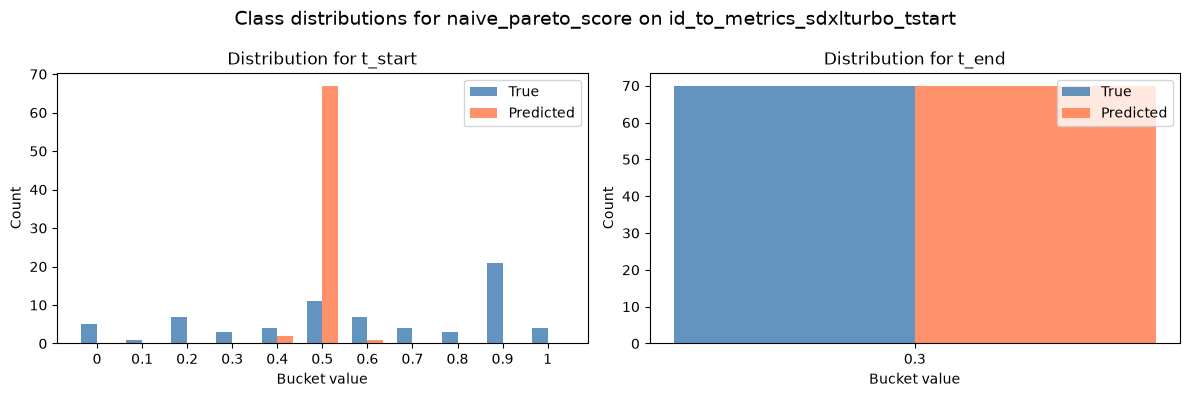

In [10]:
"""
Compare the true and predicted bucket-index frequency distributions on the test set as
side-by-side bar charts. A well-calibrated model should reproduce the shape of the true
distribution; a collapsed distribution (predictions concentrated on a few buckets)
indicates the model is defaulting to high-frequency classes.
"""

r = results["test"]
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "Distribution for t_start", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "Distribution for t_end",   N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    x = np.arange(n_buckets)
    true_counts = np.bincount(r[true_key], minlength=n_buckets)
    pred_counts = np.bincount(r[pred_key], minlength=n_buckets)
    ax.bar(x - width/2, true_counts, width, label="True",      color="steelblue", alpha=0.85)
    ax.bar(x + width/2, pred_counts, width, label="Predicted", color="coral",     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("Bucket value"); ax.set_ylabel("Count")
    ax.set_title(title); ax.legend()

fig.suptitle(f"Class distributions for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


### 8. Per-Bucket Accuracy

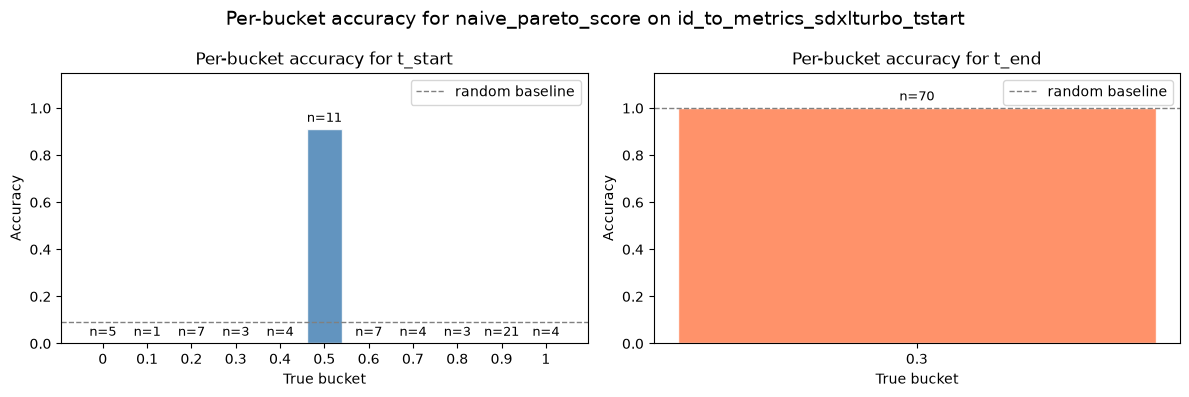

In [11]:
"""
Show exact-match accuracy broken down by true bucket for both heads on the test set.
Each bar is annotated with the sample count in that bucket, making it clear whether
low accuracy on a particular bucket reflects a genuine failure mode or simply sparse
support. The dashed line marks the random-chance accuracy for reference.
"""

r = results["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "Per-bucket accuracy for t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "Per-bucket accuracy for t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    accs, counts = [], []
    for bucket in range(n_buckets):
        mask = r[true_key] == bucket
        n = mask.sum()
        acc = (r[pred_key][mask] == bucket).mean() if n > 0 else float("nan")
        accs.append(acc)
        counts.append(n)
    bars = ax.bar(range(n_buckets), accs, color=color, alpha=0.85, edgecolor="white")
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"n={n}", ha="center", va="bottom", fontsize=9)
    ax.axhline(1/n_buckets, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_xticks(range(n_buckets)); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.15); ax.set_title(title); ax.legend()

fig.suptitle(f"Per-bucket accuracy for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


### 9. Scatter: Predicted vs. True Bucket Indices

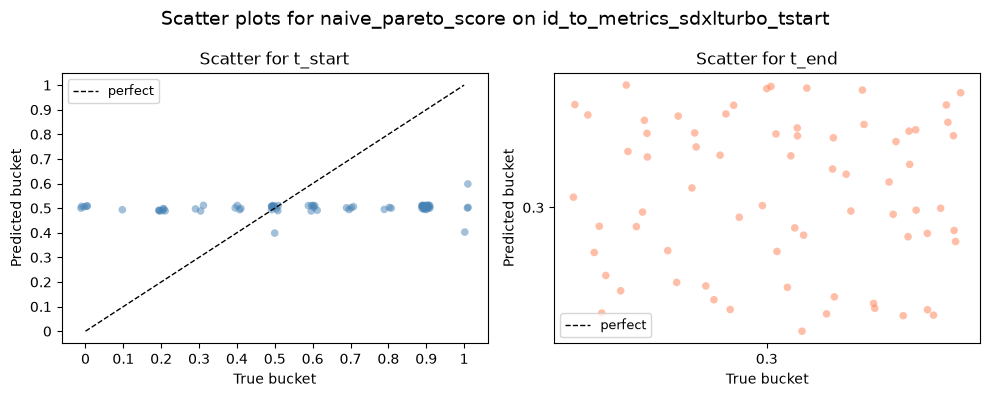

In [12]:
"""
Scatter predicted vs true bucket indices for both heads on the test set, with small
random jitter added to separate overlapping points. Points on the dashed diagonal are
exact matches; the spread around it shows the typical magnitude and direction of errors
for each region of the output space.
"""

r = results["test"]
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    jx = r[true_key] + rng.uniform(-jitter, jitter, len(r[true_key]))
    jy = r[pred_key] + rng.uniform(-jitter, jitter, len(r[pred_key]))
    ax.scatter(jx, jy, alpha=0.5, s=30, color=color, edgecolors="none")
    ax.plot([0, n_buckets - 1], [0, n_buckets - 1], "k--", linewidth=1, label="perfect")
    ax.set_xticks(range(n_buckets)); ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels); ax.set_yticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Predicted bucket")
    ax.set_title(f"Scatter for {title}")
    ax.legend(fontsize=9)

fig.suptitle(f"Scatter plots for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


## 10. Head Internals

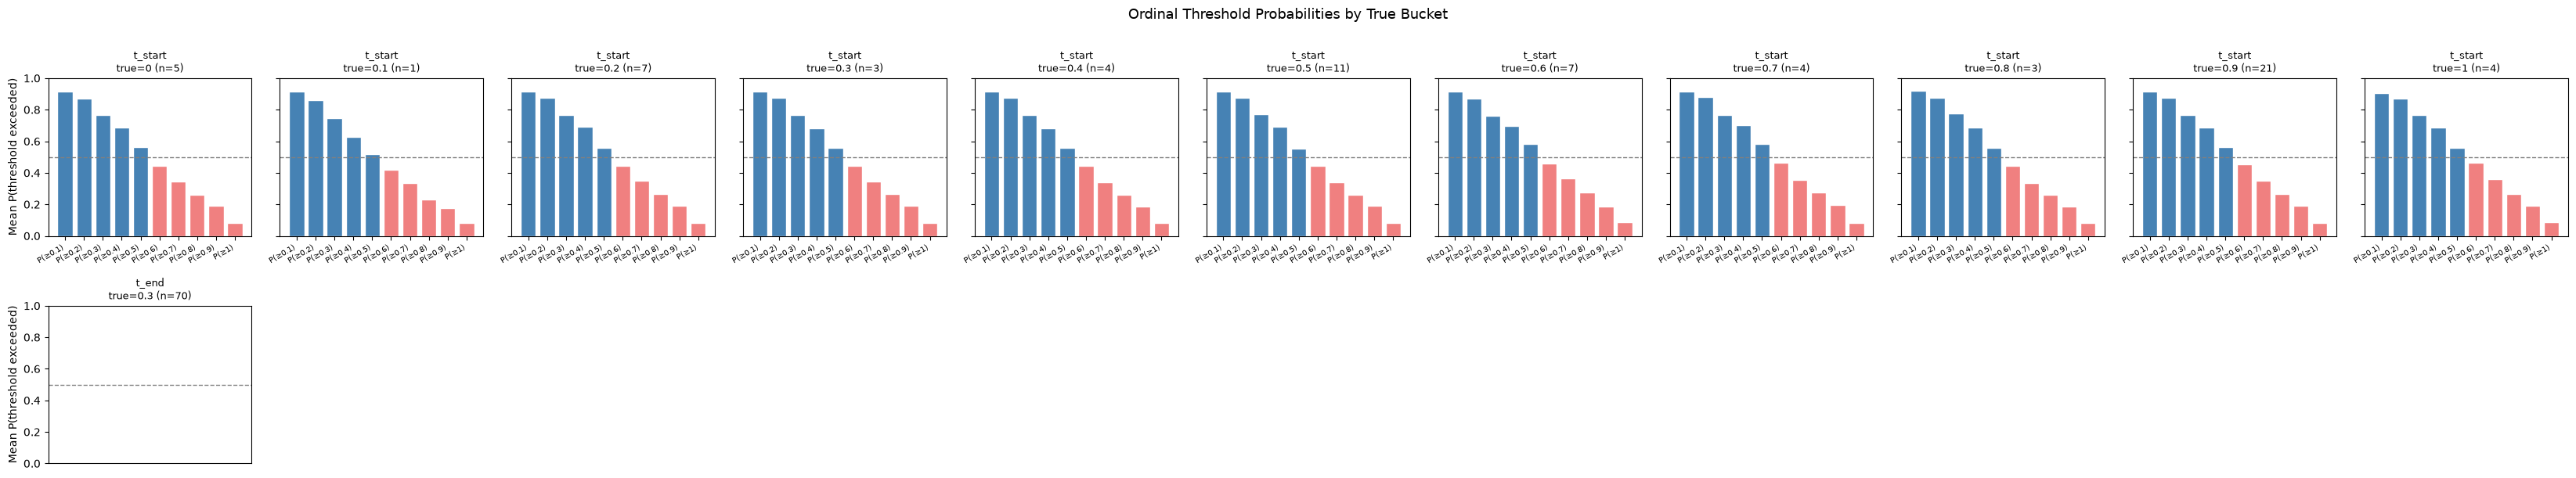

In [13]:
"""
Inspect the raw outputs of each head to understand how the model uses its internal
representation. For CORAL heads, this plots the mean sigmoid-transformed threshold
probability at each of the K-1 thresholds, grouped by true bucket: a well-behaved head
should show probabilities close to 1 for low thresholds and tapering to 0, with the
crossover point shifting right as the true bucket increases. For MSE heads, box plots
show the distribution of raw sigmoid scalars per true bucket, with the target bucket
float values overlaid as reference lines.
"""

def sigmoid(x): return 1 / (1 + np.exp(-x))

r = results["test"]

if model.head_type == "CORAL":
    # --- CORAL: average sigmoid(logit) per threshold, grouped by true bucket ---
    logits1 = r["raw_start"]   # (N, N_BUCKETS_START-1)
    logits2 = r["raw_end"]     # (N, N_BUCKETS_END-1)
    true1   = r["true_start"]
    true2   = r["true_end"]

    threshold_labels_start = [f"P(≥{v:.3g})" for v in bucket_vals_start[1:]]
    threshold_labels_end   = [f"P(≥{v:.3g})" for v in bucket_vals_end[1:]]

    n_cols = max(N_BUCKETS_START, N_BUCKETS_END)
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6), sharey=True)

    for head_idx, (logits, true, head_name, n_buckets, bucket_labels, thr_labels) in enumerate([
        (logits1, true1, "t_start", N_BUCKETS_START, BUCKET_LABELS_START, threshold_labels_start),
        (logits2, true2, "t_end",   N_BUCKETS_END,   BUCKET_LABELS_END,   threshold_labels_end),
    ]):
        for bucket in range(n_buckets):
            ax = axes[head_idx][bucket]
            mask = true == bucket
            if mask.sum() == 0:
                ax.set_visible(False)
                continue
            probs = sigmoid(logits[mask]).mean(axis=0)  # (n_buckets-1,)
            colors = ["steelblue" if p > 0.5 else "lightcoral" for p in probs]
            ax.bar(range(n_buckets - 1), probs, color=colors, edgecolor="white")
            ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
            ax.set_xticks(range(n_buckets - 1))
            ax.set_xticklabels(thr_labels, fontsize=7, rotation=30, ha="right")
            ax.set_ylim(0, 1)
            ax.set_title(f"{head_name}\ntrue={bucket_labels[bucket]} (n={mask.sum()})", fontsize=9)
            if bucket == 0:
                ax.set_ylabel("Mean P(threshold exceeded)")
        for bucket in range(n_buckets, n_cols):
            axes[head_idx][bucket].set_visible(False)

    plt.suptitle("Ordinal Threshold Probabilities by True Bucket", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

else:
    # --- MSE: raw predicted scalar (sigmoid output) vs true bucket value ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, raw_key, true_key, head_name, n_buckets, bucket_vals, bucket_labels, color in [
        (axes[0], "raw_start", "true_start", "t_start", N_BUCKETS_START, bucket_vals_start, BUCKET_LABELS_START, "steelblue"),
        (axes[1], "raw_end",   "true_end",   "t_end",   N_BUCKETS_END,   bucket_vals_end,   BUCKET_LABELS_END,   "coral"),
    ]:
        raw  = r[raw_key]    # (N,) sigmoid scalars
        true = r[true_key]   # (N,) bucket indices

        # Box-per-true-bucket of raw predicted values
        data_by_bucket = [raw[true == b] for b in range(n_buckets)]
        bp = ax.boxplot(data_by_bucket, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        # Overlay the true bucket values as horizontal reference lines
        for i, v in enumerate(bucket_vals):
            ax.axhline(v, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_xticks(range(1, n_buckets + 1))
        ax.set_xticklabels(bucket_labels)
        ax.set_xlabel("True bucket")
        ax.set_ylabel("Raw predicted value (sigmoid output)")
        ax.set_title(f"{head_name} — Predicted scalar by true bucket")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


## 11. Qualitative Examples

In [14]:
"""
Print representative qualitative examples from the test set: the four samples where both
heads predicted exactly correctly, and the four samples with the largest maximum bucket
error across either head. Comparing the prompt pairs in each group gives intuition about
which types of edits the model finds easy versus hard.
"""

r = results["test"]

test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["pred_start"] = bucket_vals_start[r["pred_start"]]
test_df_copy["pred_end"]   = bucket_vals_end[r["pred_end"]]
test_df_copy["err_start"]  = abs(r["pred_start"] - r["true_start"])
test_df_copy["err_end"]    = abs(r["pred_end"]   - r["true_end"])
test_df_copy["max_err"]    = test_df_copy[["err_start", "err_end"]].max(axis=1)

# Show: 4 correct predictions and 4 worst mistakes
correct = test_df_copy[(test_df_copy.err_start == 0) & (test_df_copy.err_end == 0)].head(4)
wrong   = test_df_copy.sort_values("max_err", ascending=False).head(4)

def show_examples(df, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for _, row in df.iterrows():
        print(f"  source: {row['source_prompt'][:80]}")
        print(f"  target: {row['target_prompt'][:80]}")
        print(f"  t_start  true={row['t_start']:.3g}  pred={row['pred_start']:.3g}")
        print(f"  t_end    true={row['t_end']:.3g}  pred={row['pred_end']:.3g}")
        print()

show_examples(correct, "Correct predictions")
show_examples(wrong,   "Largest errors")



  Correct predictions
  source: three white [dumplings] on brown bowl
  target: three white [sushi] on brown bowl
  t_start  true=0.5  pred=0.5
  t_end    true=0.3  pred=0.3

  source: a [pepper] on the table
  target: a [pear] on the table
  t_start  true=0.5  pred=0.5
  t_end    true=0.3  pred=0.3

  source: [two boats are docked on the shore of] a lake
  target: a lake
  t_start  true=0.5  pred=0.5
  t_end    true=0.3  pred=0.3

  source: a woman with [long curly hair]
  target: a woman with [short curly hair]
  t_start  true=0.5  pred=0.5
  t_end    true=0.3  pred=0.3


  Largest errors
  source: white flowers are [growing] in the grass
  target: white flowers are [fade] in the grass
  t_start  true=1  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a woman in a black dress and hat stands in front of [a large wall]
  target: a woman in a black dress and hat stands in front of [a large park]
  t_start  true=0  pred=0.5
  t_end    true=0.3  pred=0.3

  source: a painting of a woma

## 13. Summary

In [15]:
"""
Print a concise test-set summary of accuracy and MAE for both heads alongside the
random-chance accuracy baseline, giving a single-glance view of overall model performance
for reporting purposes.
"""

m = compute_metrics(results["test"])
print("Test-set summary")
print(f"  MAE  t_start: {m['mae_start']:.3f}   t_end: {m['mae_end']:.3f}")
print(f"  Acc  t_start: {m['acc_start']:.1%}  t_end: {m['acc_end']:.1%}")
print(f"  Joint accuracy (both correct): {m['acc_both']:.1%}")
print(f"  Random-chance accuracy: {1/N_BUCKETS_START:.1%} / {1/N_BUCKETS_END:.1%}")


Test-set summary
  MAE  t_start: 2.700   t_end: 0.000
  Acc  t_start: 14.3%  t_end: 100.0%
  Joint accuracy (both correct): 14.3%
  Random-chance accuracy: 9.1% / 100.0%
